#### Reinforcement Learning Agent for Smart charging Decisions

This notebook implements an intelligent EV charging agent using **Deep Q-Networks (DQN)**.

**Problem setting:** An electric taxi driver arrives home at 2 p.m. and must leave at 4 p.m. 
During the 2-hour window (8 × 15-min slots), an automated agent decides the charging power 
every 15 minutes. The energy demand after departure is stochastic (Normal distribution). 
The agent must balance minimizing exponential charging costs against the risk of insufficient charge.

**Approach:**
- **Environment:** SimPy-based discrete-event simulation wrapped in a Gymnasium interface
- **Agent:** Deep Q-Network with experience replay and target network
- **Actions:** 4 discrete charging levels (off / low / medium / high → 0, 7.3, 14.7, 22 kW)



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque, namedtuple
from itertools import count

import simpy
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


#### Markov Decision Process Definition

#### State Space
Each state $s_t$ is a 2-dimensional continuous vector:

| Component | Description | Range |
|-----------|-------------|-------|
| SoC | Current battery state of charge (kWh) | $[0, C_{\text{max}}]$ |
| Time slot | Current 15-min period index (normalized) | $[0, 1]$ |

#### Action Space
Four discrete charging levels, mapped to continuous power values:

| Action | Label | Power (kW) | Energy per slot (15min) (kWh) | Reward | ${{-c*e^{(p_t/p_{max})}}}$ |
|--------|-------|-----------|----------------------|------------|---------|
| 0 | Off | 0.0 | 0.0 | -4.00 | $-4{*}1$|
| 1 | Low | 7.3 | 1.83 | -5.58 | $-4{*}1.39$|
| 2 | Medium | 14.7 | 3.67 | -7.80 | $-4{*}1.95$|
| 3 | High | 22.0 | 5.50 | -10.87 | $-4{*}2.72$|

#### Reward Function
$$R_t = -c \cdot e^{p_t / p_{\max}}$$

where $c = 4.0$ ¢/kWh is a constant cost coefficient based on typical Chicago afternoon electricity supply prices (ComEd Hourly Pricing, 2018–2022 average) and $p_t / p_{\max}$ normalizes the charging power to $[0, 1]$.

At episode end (after slot 7), an additional penalty applies if the accumulated charge is below the stochastic demand $D \sim \mathcal{N}(\mu=30, \sigma=5)$:

$$R_{\text{penalty}} = -\lambda \cdot \max(0, D - \text{SoC}_{\text{final}})$$

where $\lambda$ is a large penalty coefficient. Per lacking kWh, a factor $\lambda$ is applied, which determines the scale of the penalty per lacking kWh.

#### Transition Dynamics
$$\text{SoC}_{t+1} = \min(\text{SoC}_t + p_t \cdot \Delta t, \; C_{\text{max}})$$

The current battery state of charge + loaded battery per timeslot, caped at the maximum battery capactiy (60kWh).


In [2]:
# ── Environment Configuration ──
ENV_CONFIG = {
    "battery_capacity_kwh": 60.0,      # Maximum battery capacity
    "initial_soc_range_kwh": [5.0, 15.0],  # Random initial SoC on arrival at 2 p.m.
    "n_slots": 8,                       # 2 hours / 15 min = 8 decision points
    "slot_duration_h": 0.25,            # 15 minutes in hours
    "max_power_kw": 22.0,              # Maximum charging rate
    "demand_mean_kwh": 30.0,           # μ of energy demand distribution
    "demand_std_kwh": 5.0,             # σ of energy demand distribution
    "penalty_coeff": 200.0,             # λ — penalty per kWh shortfall
    "power_levels_kw": [0.0, 7.3, 14.7, 22.0],  # Discrete action mapping
    "cost_coeff": 4.0,                  # Constant c (¢/kWh), based on ComEd avg afternoon supply price
}
# Source: https://hourlypricing.comed.com/live-prices/year/


print("Energy per slot (kWh) per action:")
for i, p in enumerate(ENV_CONFIG["power_levels_kw"]):
    print(f"  Action {i} ({p:5.1f} kW) → {p * ENV_CONFIG['slot_duration_h']:.2f} kWh")
print(f"\nMax chargeable in 2h: {ENV_CONFIG['max_power_kw'] * ENV_CONFIG['n_slots'] * ENV_CONFIG['slot_duration_h']:.1f} kWh")
print(f"Demand distribution: N({ENV_CONFIG['demand_mean_kwh']}, {ENV_CONFIG['demand_std_kwh']}²)")


Energy per slot (kWh) per action:
  Action 0 (  0.0 kW) → 0.00 kWh
  Action 1 (  7.3 kW) → 1.82 kWh
  Action 2 ( 14.7 kW) → 3.67 kWh
  Action 3 ( 22.0 kW) → 5.50 kWh

Max chargeable in 2h: 44.0 kWh
Demand distribution: N(30.0, 5.0²)


In [3]:
class EVChargingEnv(gym.Env):
    """
    Electric Vehicle Smart Charging Environment.
    
    Uses SimPy internally for discrete-event simulation of the 2-hour charging
    window. Exposes a standard Gymnasium interface for RL agent interaction.
    """
    
    metadata = {"render_modes": ["human"]}
    
    def __init__(self, config=None):
        super().__init__()
        # Initialise cfg, as ENV_CONFIG, with all configuration parameters prior defined
        self.cfg = config or ENV_CONFIG
        
        # Action space: 4 discrete charging levels
        self.action_space = spaces.Discrete(len(self.cfg["power_levels_kw"]))
        
        # State (Observation) space: [SoC, time_slot (normalized)], 2D Float Vector [0.0 - 60.0 absolute State, normalized Slot 0.0-1.0]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0], dtype=np.float32),
            high=np.array([self.cfg["battery_capacity_kwh"], 1.0], dtype=np.float32),
        )
        
        # Internal state, battery SoC (kWh), current slot index, cumulative cost, and history of slots
        self.soc = 0.0
        self.current_slot = 0
        self.episode_cost = 0.0
        self.slot_history = []
        
        # SimPy placeholders, to be filled in reset()
        self._simpy_env = None
        self._action_event = None
        self._step_result = None
        
    # Construct state/observation vector    
    def _get_obs(self):
        """Construct observation vector."""
        normalized_slot = self.current_slot / (self.cfg["n_slots"] - 1)
        return np.array([self.soc, normalized_slot], dtype=np.float32)
    
    # SimPy process for charging
    def _charging_process(self, env):
        """SimPy process: runs through all 8 charging slots."""
        for slot in range(self.cfg["n_slots"]):
            self.current_slot = slot
            
            # Wait for agent's action
            self._action_event = env.event()
            yield self._action_event
            action = self._action_event.value
            
            # Apply charging
            old_soc = self.soc
            power_kw = self.cfg["power_levels_kw"][action]
            energy_kwh = power_kw * self.cfg["slot_duration_h"]
            self.soc = min(self.soc + energy_kwh, self.cfg["battery_capacity_kwh"])

            # Store how much energy was actually added (not how much was requested/paid for)
            actual_energy = self.soc - old_soc
            
            # Compute cost: c * e^(p / p_max)
            c = self.cfg["cost_coeff"]
            slot_cost = c * np.exp(power_kw / self.cfg["max_power_kw"])
            self.episode_cost += slot_cost
            
            # Reward = - episode_costs (later potential penalty for unmet demand will be added (-))
            reward = -slot_cost
            
            # Log
            self.slot_history.append({
                "slot": slot,
                "action": action,
                "power_kw": power_kw,
                "energy_kwh": actual_energy,
                "soc_after": self.soc,
                "cost": slot_cost,
            })
            
            terminated = (slot == self.cfg["n_slots"] - 1)
            
            # At episode end: realize demand and apply penalty if SoC < demand
            penalty = 0.0
            demand = None
            if terminated:
                demand = np.random.normal(
                    self.cfg["demand_mean_kwh"], self.cfg["demand_std_kwh"]
                )
                demand = max(0, demand)  # Demand cannot be negative
                shortfall = max(0, demand - self.soc)
                if shortfall > 0:
                    penalty = self.cfg["penalty_coeff"] * shortfall
                    reward -= penalty
            
            # Prepare step result for Gym interface (Simpy & Gym integration)
            self._step_result = (
                self._get_obs(), reward, terminated, False,
                # Additional info for debugging/analysis not used by Gym/Agent
                {"cost": slot_cost, "penalty": penalty, "demand": demand, "soc": self.soc}
            )
            
            # Simulated 15min in SimPy to end at next time slot (or end of episode) for next for-loop-iteration
            yield env.timeout(15)
    

    # Gym interface method: reset, for initializing the environment and starting a new episode
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.soc = np.random.uniform(*self.cfg["initial_soc_range_kwh"])
        self.current_slot = 0
        self.episode_cost = 0.0
        self.slot_history = []
        
        # Initialize SimPy environment and start charging process
        self._simpy_env = simpy.Environment()
        self._simpy_env.process(self._charging_process(self._simpy_env))
        # Run until the process yields the first action_event, not step(self, action) --> but step --> yields,...

        # Advance SimPy simulation to the next "yield" as self.Environment.step() (SimPy internal method)
        self._simpy_env.step()
        
        return self._get_obs(), {}
    
    # Gym interface method: step, for executing one action and advancing the environment
    def step(self, action):
        """Execute one charging decision."""
        # Trigger the action event in SimPy
        self._action_event.succeed(value=action)
        
        # Advance SimPy simulation (processes the action + timeout)
        try:
            # Simpy Steps
            self._simpy_env.step()  # Process action
            self._simpy_env.step()  # Process timeout → next slot or end
        except StopIteration:
            pass  # End of simulation
        
        return self._step_result


# Quick sanity check
env = EVChargingEnv(ENV_CONFIG)
obs, _ = env.reset()
print(f"Initial observation: SoC={obs[0]:.1f} kWh, slot={obs[1]:.2f}")

total_reward = 0
for step in range(8):
    obs, reward, terminated, truncated, info = env.step(3)  # Always charge at max
    total_reward += reward
    print(f"  Slot {step}: SoC={info['soc']:.1f} kWh, cost={info['cost']:.2f}, reward={reward:.2f}", end="")
    if terminated:
        print(f"  | Demand={info['demand']:.1f}, penalty={info['penalty']:.2f}")
    else:
        print()
print(f"Total reward (always-max policy): {total_reward:.2f}")


Initial observation: SoC=8.7 kWh, slot=0.00
  Slot 0: SoC=14.2 kWh, cost=10.87, reward=-10.87
  Slot 1: SoC=19.7 kWh, cost=10.87, reward=-10.87
  Slot 2: SoC=25.2 kWh, cost=10.87, reward=-10.87
  Slot 3: SoC=30.7 kWh, cost=10.87, reward=-10.87
  Slot 4: SoC=36.2 kWh, cost=10.87, reward=-10.87
  Slot 5: SoC=41.7 kWh, cost=10.87, reward=-10.87
  Slot 6: SoC=47.2 kWh, cost=10.87, reward=-10.87
  Slot 7: SoC=52.7 kWh, cost=10.87, reward=-10.87  | Demand=24.4, penalty=0.00
Total reward (always-max policy): -86.99


Charging at max power the whole time avoids any shortfall penalty here, but it's not a real strategy, just a fixed rule that ignores cost. It racks up the highest possible cost every episode (-10.87 per slot, -87 total), so it gives us a safe but expensive baseline to compare the trained agent against.

## Deep Q-Network Agent

### Why DQN?

We choose DQN over alternative RL methods for this problem because:

1. **Small discrete action space (4 actions):** Q-learning-based methods excel here. Policy gradient methods (REINFORCE, Actor-Critic) are unnecessarily complex for so few actions.
2. **Continuous state space:** Tabular Q-learning would require discretizing the SoC, losing precision. A neural network naturally handles continuous inputs.
3. **Sample efficiency:** Unlike Monte Carlo methods that learn only at episode end, DQN learns from individual transitions via experience replay, converging faster.
4. **Multi-Armed Bandits** cannot model sequential decisions where action at $t$ affects state at $t+1$.
5. **Tabular SARSA/Q-Learning** would require discretizing the continuous SoC, losing resolution.

### Architecture
- **Input:** 2-dimensional state vector (SoC, normalized time slot)
- **Hidden layers:** Two fully connected layers with 128 neurons each and ReLU activation
- **Output:** 4 Q-values, one per discrete charging action
- **Stabilization:** Target network (soft-updated) + experience replay buffer


In [4]:
# ── Replay Buffer ──
Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "done"))


class ReplayBuffer:
    """Fixed-size experience replay buffer."""
    
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)


# ── Q-Network ──
class QNetwork(nn.Module):
    """Feedforward neural network for Q-value approximation."""
    
    def __init__(self, state_dim, n_actions, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )
    
    def forward(self, x):
        return self.net(x)


# ── DQN Agent ──
class DQNAgent:
    """Deep Q-Network agent with experience replay and target network."""
    
    def __init__(self, state_dim, n_actions, config=None):
        cfg = config or {}
        self.n_actions = n_actions
        self.gamma = cfg.get("gamma", 0.99)
        self.lr = cfg.get("lr", 1e-3)
        self.batch_size = cfg.get("batch_size", 64)
        self.buffer_size = cfg.get("buffer_size", 10_000)
        self.tau = cfg.get("tau", 0.005)  # Soft update rate
        self.eps_start = cfg.get("eps_start", 1.0)
        self.eps_end = cfg.get("eps_end", 0.05)
        self.eps_decay = cfg.get("eps_decay", 500)
        
        # Networks
        self.policy_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net = QNetwork(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.memory = ReplayBuffer(self.buffer_size)
        self.steps_done = 0
    
    def select_action(self, state, greedy=False):
        """Epsilon-greedy action selection."""
        eps = self.eps_end + (self.eps_start - self.eps_end) * np.exp(
            -self.steps_done / self.eps_decay
        )
        self.steps_done += 1
        
        if greedy or random.random() > eps:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                return self.policy_net(state_t).argmax(dim=1).item()
        else:
            return random.randrange(self.n_actions)
    
    def optimize(self):
        """Sample a batch and perform one gradient step."""
        if len(self.memory) < self.batch_size:
            return None
        
        batch = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*batch))
        
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(batch.reward).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).unsqueeze(1).to(device)
        
        # Current Q-values
        q_values = self.policy_net(states).gather(1, actions)
        
        # Target Q-values (Bellman equation)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)
        
        loss = F.mse_loss(q_values, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        # Soft update target network
        for tp, pp in zip(self.target_net.parameters(), self.policy_net.parameters()):
            tp.data.copy_(self.tau * pp.data + (1 - self.tau) * tp.data)
        
        return loss.item()

print("DQN Agent initialized.")
print(f"  Policy network: {sum(p.numel() for p in QNetwork(2, 4).parameters())} parameters")


DQN Agent initialized.
  Policy network: 12932 parameters


#### Training Agent

The agent trains for 5000 episodes. Epsilon decays from 1.0 to 0.05 over the run, so early episodes are mostly random exploration and later ones increasingly follow the learned Q-values. Reward, penalty and final SoC are averaged over the last 100 episodes and printed every 250 episodes to track convergence.

In [5]:
# ── Training Configuration ──
TRAIN_CONFIG = {
    "gamma": 0.95,
    "lr": 1e-4,
    "batch_size": 64,
    "buffer_size": 50_000,
    "tau": 0.0005,
    "eps_start": 1.0,
    "eps_end": 0.05,
    "eps_decay": 5000,
}

N_EPISODES = 5000

# ── Initialize ──
env = EVChargingEnv(ENV_CONFIG)
agent = DQNAgent(
    state_dim=2,
    n_actions=env.action_space.n,
    config=TRAIN_CONFIG,
)

# ── Training Loop ──
episode_rewards = []
episode_costs = []
episode_penalties = []
episode_socs = []
losses = []

for ep in range(N_EPISODES):
    state, _ = env.reset()
    total_reward = 0.0
    ep_penalty = 0.0
    
    for t in range(ENV_CONFIG["n_slots"]):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        
        agent.memory.push(state, action, reward, next_state, float(terminated))
        loss = agent.optimize()
        if loss is not None:
            losses.append(loss)
        
        total_reward += reward
        ep_penalty += info["penalty"]
        state = next_state
        
        if terminated:
            break
    
    episode_rewards.append(total_reward)
    episode_costs.append(env.episode_cost)
    episode_penalties.append(ep_penalty)
    episode_socs.append(env.soc)
    
    if (ep + 1) % 250 == 0:
        avg_r = np.mean(episode_rewards[-100:])
        avg_p = np.mean(episode_penalties[-100:])
        avg_soc = np.mean(episode_socs[-100:])
        print(f"Episode {ep+1:>5} | Avg Reward (100): {avg_r:>8.2f} | "
              f"Avg Penalty: {avg_p:>6.2f} | Avg Final SoC: {avg_soc:>5.1f} kWh")

print("\nTraining complete.")
# Optimal negative reward, -55 & -65


Episode   250 | Avg Reward (100):  -251.53 | Avg Penalty: 186.36 | Avg Final SoC:  39.0 kWh


Episode   500 | Avg Reward (100):   -97.31 | Avg Penalty:  25.25 | Avg Final SoC:  43.3 kWh


Episode   750 | Avg Reward (100):  -105.48 | Avg Penalty:  29.42 | Avg Final SoC:  45.9 kWh


Episode  1000 | Avg Reward (100):   -79.84 | Avg Penalty:   0.00 | Avg Final SoC:  49.3 kWh


Episode  1250 | Avg Reward (100):  -159.60 | Avg Penalty:  80.99 | Avg Final SoC:  47.6 kWh


...

Episode  4000 | Avg Reward (100):   -78.28 | Avg Penalty:   0.00 | Avg Final SoC:  48.2 kWh


Episode  4250 | Avg Reward (100):   -79.28 | Avg Penalty:   1.15 | Avg Final SoC:  47.9 kWh


Episode  4500 | Avg Reward (100):   -75.52 | Avg Penalty:   0.00 | Avg Final SoC:  46.1 kWh


Episode  4750 | Avg Reward (100):   -74.59 | Avg Penalty:   0.00 | Avg Final SoC:  45.4 kWh


Episode  5000 | Avg Reward (100):   -72.86 | Avg Penalty:   0.00 | Avg Final SoC:  44.4 kWh

Training complete.


Average penalty falls close to zero by episode 1000, then spikes back up around episode 1250 as epsilon-driven exploration still occasionally pushes the agent into risky states, before settling near zero for good from about episode 2000 onward. Average reward follows the same shape and ends up around -73 to -80 by episode 5000, clearly better than the -87 always-max baseline, so the agent found charging schedules that are both cheap and safe rather than just safe.

#### Training Curves

The four panels below track reward, final SoC, penalty and loss across training, each smoothed with a moving average to cut through per-episode noise.

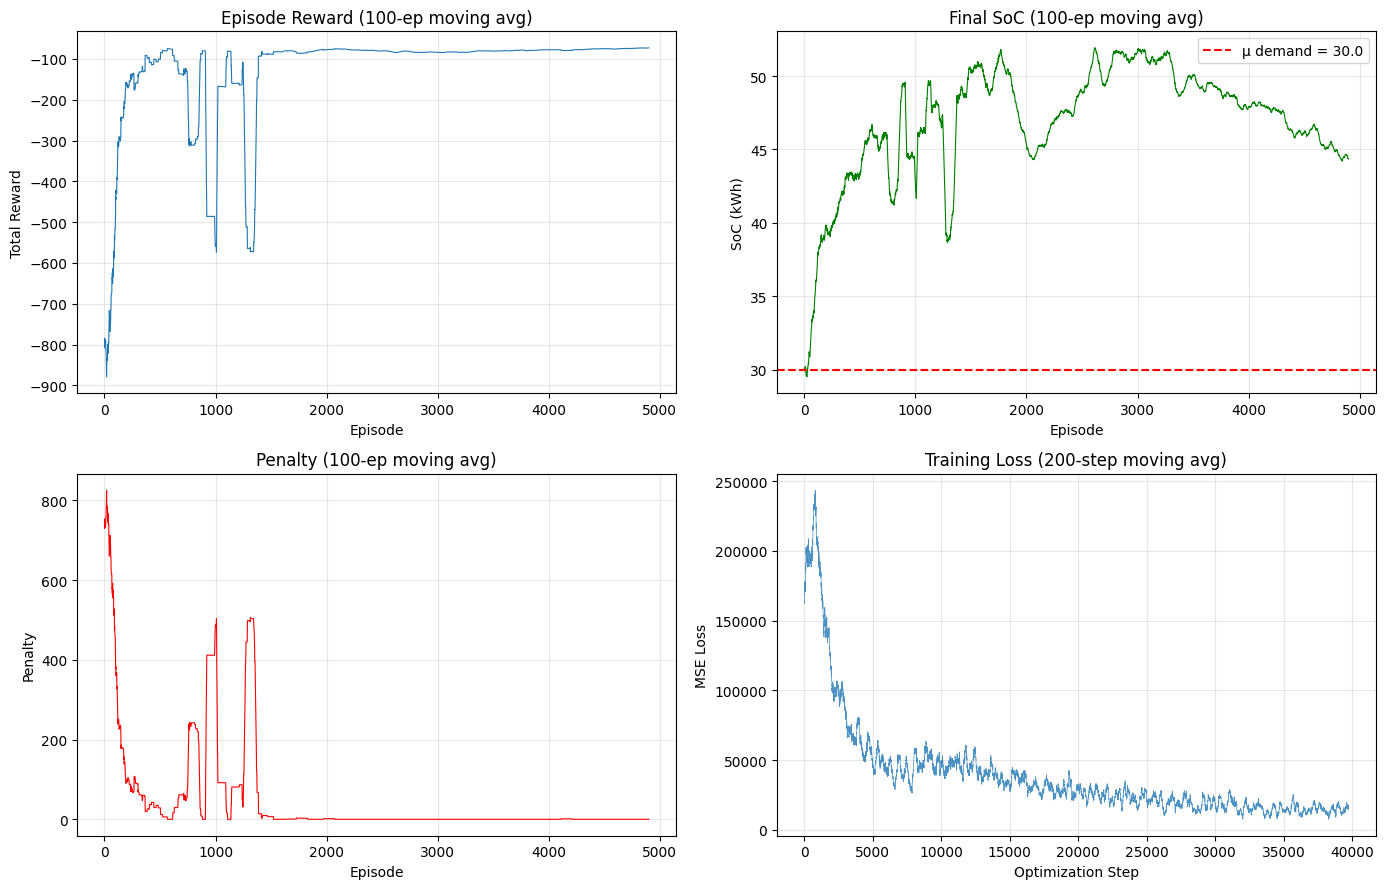

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Episode rewards (smoothed)
window = 100
smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode="valid")
axes[0, 0].plot(smoothed_rewards, linewidth=0.8)
axes[0, 0].set_title("Episode Reward (100-ep moving avg)")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Total Reward")
axes[0, 0].grid(True, alpha=0.3)

# Final SoC
smoothed_soc = np.convolve(episode_socs, np.ones(window)/window, mode="valid")
axes[0, 1].plot(smoothed_soc, linewidth=0.8, color="green")
axes[0, 1].axhline(y=ENV_CONFIG["demand_mean_kwh"], color="red", linestyle="--", label=f'μ demand = {ENV_CONFIG["demand_mean_kwh"]}')
axes[0, 1].set_title("Final SoC (100-ep moving avg)")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("SoC (kWh)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Penalties
smoothed_pen = np.convolve(episode_penalties, np.ones(window)/window, mode="valid")
axes[1, 0].plot(smoothed_pen, linewidth=0.8, color="red")
axes[1, 0].set_title("Penalty (100-ep moving avg)")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Penalty")
axes[1, 0].grid(True, alpha=0.3)

# Training loss
if losses:
    loss_window = min(200, len(losses))
    smoothed_loss = np.convolve(losses, np.ones(loss_window)/loss_window, mode="valid")
    axes[1, 1].plot(smoothed_loss, linewidth=0.5, alpha=0.8)
    axes[1, 1].set_title(f"Training Loss ({loss_window}-step moving avg)")
    axes[1, 1].set_xlabel("Optimization Step")
    axes[1, 1].set_ylabel("MSE Loss")
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Reward climbs fast at first, then hits a rocky patch between roughly episode 750 and 1350 where a handful of episodes tank to -500 or worse, before settling into a stable band around -75 to -100 from episode 1500 onward. Final SoC tells the same story: it climbs well above the 30 kWh demand mean early on, dips during that same rocky patch, then holds in the mid-40s to low-50s kWh, a comfortable double-digit buffer rather than a razor-thin one. That patch lines up exactly with the penalty spike around episode 1250, still visible above, epsilon-driven exploration briefly pushes the agent back into risky territory before it locks in. Training loss falls sharply over the first few thousand steps and then flattens out, still noisy since the target network keeps shifting under a moving policy.

## Best Policy Visualization

The training curves show the agent got better, but not what it actually decided to do. To see that, we pull the greedy policy out of the trained Q-network: for every (SoC, slot) combination, take the action with the highest Q-value. In practice the network almost never picks anything other than "charge at max" or "ease off", so instead of plotting all four actions we boil the policy down to one line: the SoC level at each decision point above which the agent stops charging at full power.

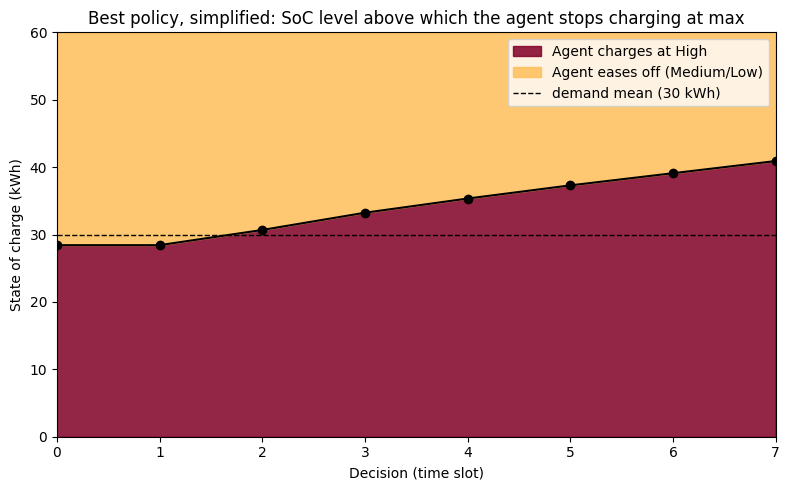

In [7]:
# ── Extract the "stop charging at max" threshold from the trained Q-network ──
soc_grid = np.linspace(0, ENV_CONFIG["battery_capacity_kwh"], 400)
slot_grid = np.arange(ENV_CONFIG["n_slots"])  # decision index, 0-7

action_labels = ["Off", "Low", "Medium", "High"]
action_cmap = plt.get_cmap("YlOrRd", 4)

throttle_threshold = []
agent.policy_net.eval()
with torch.no_grad():
    for decision in slot_grid:
        observed_slot = max(decision - 1, 0)  # slot value the agent actually receives at this decision
        normalized_slot = observed_slot / (ENV_CONFIG["n_slots"] - 1)
        states = np.stack([soc_grid, np.full_like(soc_grid, normalized_slot)], axis=1)
        states_t = torch.FloatTensor(states).to(device)
        actions = agent.policy_net(states_t).argmax(dim=1).cpu().numpy()
        below_max = np.where(actions < 3)[0]  # first SoC where the agent eases off
        threshold = soc_grid[below_max[0]] if len(below_max) else ENV_CONFIG["battery_capacity_kwh"]
        throttle_threshold.append(threshold)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(slot_grid, 0, throttle_threshold, color=action_cmap(3 / 3), alpha=0.85,
                 label="Agent charges at High")
ax.fill_between(slot_grid, throttle_threshold, ENV_CONFIG["battery_capacity_kwh"], color=action_cmap(1 / 3), alpha=0.85,
                 label="Agent eases off (Medium/Low)")
ax.plot(slot_grid, throttle_threshold, color="black", linewidth=1.5, marker="o")
ax.axhline(ENV_CONFIG["demand_mean_kwh"], color="black", linestyle="--", linewidth=1,
           label=f'demand mean ({ENV_CONFIG["demand_mean_kwh"]:.0f} kWh)')
ax.set_xticks(slot_grid)
ax.set_xlim(0, ENV_CONFIG["n_slots"] - 1)
ax.set_ylim(0, ENV_CONFIG["battery_capacity_kwh"])
ax.set_xlabel("Decision (time slot)")
ax.set_ylabel("State of charge (kWh)")
ax.set_title("Best policy, simplified: SoC level above which the agent stops charging at max")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The threshold climbs steadily across the episode, from around 28 kWh at the first couple of decisions to around 41 kWh by the last one. That direction makes sense: early on, easing off too soon and being wrong about demand still leaves several slots to correct it, but near the end there's no time left to fix a bad guess, so the agent needs a bigger banked buffer before it's willing to stop charging at max. The line sits just below the 30 kWh demand mean at first and pulls well ahead of it as the episode runs out.

To make the policy concrete, we also run one episode greedily (no exploration) and trace the SoC and the chosen action slot by slot.

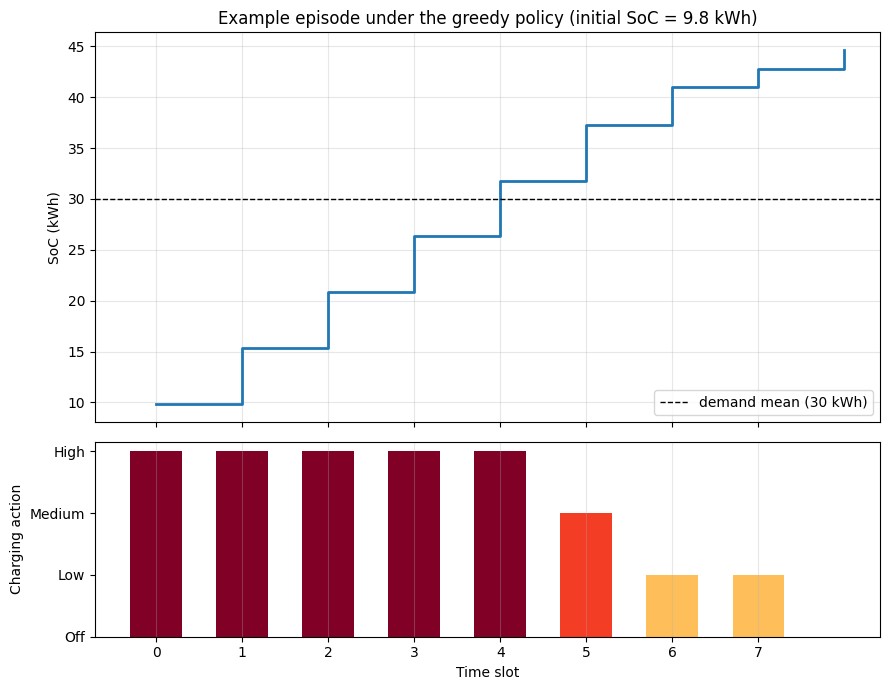

Actions taken: ['High', 'High', 'High', 'High', 'High', 'Medium', 'Low', 'Low']
Final SoC: 44.6 kWh


In [8]:
# ── Example episode under the greedy policy ──
env = EVChargingEnv(ENV_CONFIG)
state, _ = env.reset()
actions_taken = []
socs = [state[0]]

for t in range(ENV_CONFIG["n_slots"]):
    action = agent.select_action(state, greedy=True)
    state, reward, terminated, truncated, info = env.step(action)
    actions_taken.append(action)
    socs.append(info["soc"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.step(range(len(socs)), socs, where="post", color="tab:blue", linewidth=2)
ax1.axhline(ENV_CONFIG["demand_mean_kwh"], color="black", linestyle="--", linewidth=1,
            label=f'demand mean ({ENV_CONFIG["demand_mean_kwh"]:.0f} kWh)')
ax1.set_ylabel("SoC (kWh)")
ax1.set_title(f"Example episode under the greedy policy (initial SoC = {socs[0]:.1f} kWh)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

bar_colors = [action_cmap(a / 3) for a in actions_taken]
ax2.bar(range(len(actions_taken)), actions_taken, color=bar_colors, width=0.6)
ax2.set_yticks(range(4))
ax2.set_yticklabels(action_labels)
ax2.set_xlabel("Time slot")
ax2.set_ylabel("Charging action")
ax2.set_xticks(range(len(actions_taken)))
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("Actions taken:", [action_labels[a] for a in actions_taken])
print(f"Final SoC: {socs[-1]:.1f} kWh")

This episode starts at a low 9.8 kWh, well under the threshold from the plot above, so the agent charges at High for the first five decisions. By decision 5 SoC has reached 37.3 kWh, just over that decision's ~37 kWh threshold, and the agent throttles down to Medium, then Low for the last two decisions as the threshold keeps climbing faster than SoC does. It finishes at 44.6 kWh, comfortably above the 30 kWh demand mean, without spending the whole episode at the most expensive charging level.